## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [ ]:
import numpy as np 
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import os
import cv2

import warnings
# filter warnings
warnings.filterwarnings('ignore')


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas. Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


---

# Lectura de imágenes y creación de datasets X,y de train y test

In [3]:
from pathlib import Path

def cargar_imagenes_desde_directorios(lista_directorios, tamano=(32, 32)):
    """
    Lee imágenes de una lista de directorios, las redimensiona y extrae la etiqueta del nombre del archivo.
    """
    X = []
    y = []
    
    # Asegurarnos de que trabajamos con una lista, aunque se pase un solo directorio
    if isinstance(lista_directorios, str) or isinstance(lista_directorios, Path):
        lista_directorios = [lista_directorios]

    for directorio in lista_directorios:
        ruta_dir = Path(directorio)
        
        # Verificar si el directorio existe
        if not ruta_dir.exists():
            print(f"Advertencia: El directorio {ruta_dir} no se encuentra.")
            continue

        # Iterar sobre todos los archivos del directorio
        for archivo in ruta_dir.iterdir():
            if archivo.is_file() and archivo.suffix.lower() in ['.jpg', '.jpeg', '.png']:
                # Leer la imagen
                imagen = cv2.imread(str(archivo))
                
                if imagen is not None:
                    # Redimensionar la imagen a 32x32
                    imagen_redimensionada = cv2.resize(imagen, tamano)
                    X.append(imagen_redimensionada)
                    
                    # Extraer la etiqueta del nombre del archivo
                    nombre_archivo = archivo.name.lower()
                    if 'dog' in nombre_archivo or 'perro' in nombre_archivo:
                        y.append('perro')
                    elif 'cat' in nombre_archivo or 'gato' in nombre_archivo:
                        y.append('gato')
                    else:
                        y.append('desconocido') # Por si hay archivos con otros nombres

    return np.array(X), np.array(y)

In [4]:
# 1. Definir las rutas
rutas_train = [
    "data/github_train_0",
    "data/github_train_1",
    "data/github_train_2",
    "data/github_train_3"
]
ruta_test = ["data/github_test"]

# 2. Cargar y procesar los datasets X e y
print("Cargando datos de entrenamiento...")
X_train, y_train = cargar_imagenes_desde_directorios(rutas_train, tamano=(32, 32))

print("Cargando datos de prueba...")
X_test, y_test = cargar_imagenes_desde_directorios(ruta_test, tamano=(32, 32))

print(f"Forma de X_train: {X_train.shape}")
print(f"Forma de y_train: {y_train.shape}")

Cargando datos de entrenamiento...
Cargando datos de prueba...
Forma de X_train: (4000, 32, 32, 3)
Forma de y_train: (4000,)


---

# Creación del modelo DL

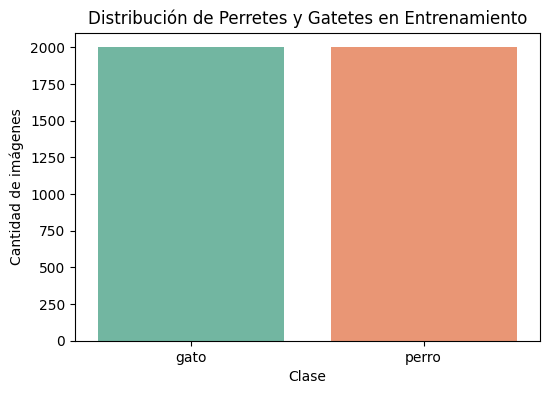

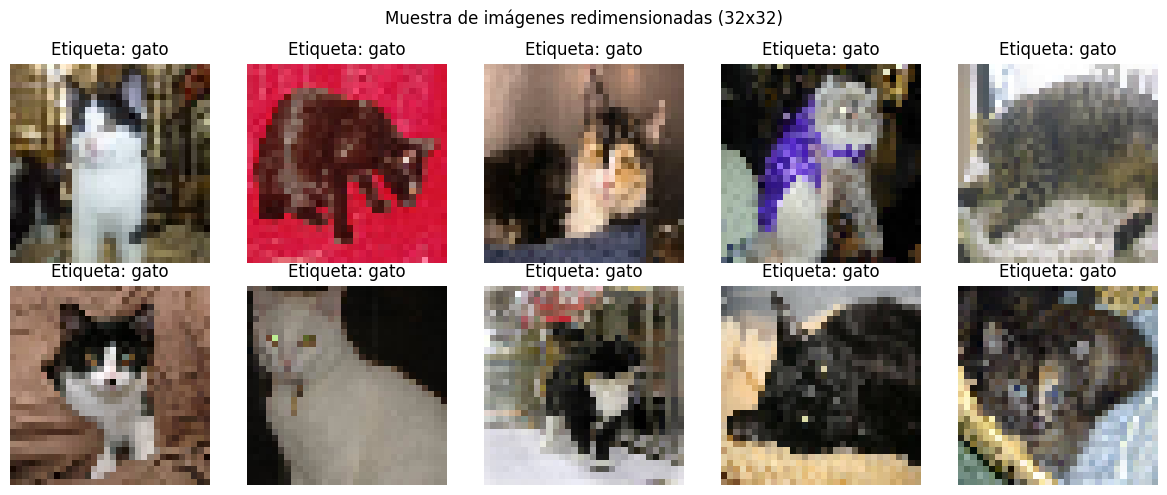

In [ ]:
# --- 1. MINIEDA: Comprobación del balanceo de clases ---
plt.figure(figsize=(6, 4))
sns.countplot(
    x=y_train, 
    palette="Set2"
    )
plt.title("Distribución de Perretes y Gatetes en Entrenamiento")
plt.xlabel("Clase")
plt.ylabel("Cantidad de imágenes")
plt.show()

# --- 2. VISUALIZACIÓN: Pintar una muestra de imágenes ---
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    # OJO: OpenCV lee las imágenes en formato BGR. 
    # Para que Matplotlib las pinte con los colores reales, pasamos a RGB.
    img_rgb = cv2.cvtColor(X_train[i], cv2.COLOR_BGR2RGB)
    
    ax.imshow(img_rgb)
    ax.set_title(f"Etiqueta: {y_train[i]}")
    ax.axis('off') # Quitamos los ejes para que quede más limpio
    
plt.suptitle("Muestra de imágenes redimensionadas (32x32)")
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Normalizamos las imágenes dividiendo entre 255.0 para que los valores estén entre 0 y 1
X_train_norm = X_train.astype('float32') / 255.0
X_test_norm = X_test.astype('float32') / 255.0

# Convertimos "perro" y "gato" en 0 y 1
le = LabelEncoder()
y_train_enc = le.fit_transform(y_train)
y_test_enc = le.transform(y_test)

# Separamos un trozo del conjunto de train para validación (ej. 20%)
X_tr, X_val, y_tr, y_val = train_test_split(
        X_train_norm, 
        y_train_enc,
        test_size=0.2, 
        random_state=42)

print(f"Las clases codificadas son: {le.classes_} -> [0, 1]")

Las clases codificadas son: ['gato' 'perro'] -> [0, 1]


In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Inicializamos el modelo secuencial
modelo = Sequential()

# --- PRIMER JUEGO CONVOLUCIONAL-POOLING ---
# 32 filtros, tamaño de ventana 3x3. Input shape es 32x32 con 3 canales (RGB)
modelo.add(Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))
# Reducimos el tamaño a la mitad quedándonos con el píxel más importante
modelo.add(MaxPooling2D((2, 2)))

# --- SEGUNDO JUEGO CONVOLUCIONAL-POOLING ---
# Aumentamos los filtros a 64 porque la imagen ahora es más pequeña pero tiene más "profundidad" de características
modelo.add(Conv2D(64, (3, 3), activation='relu'))
modelo.add(MaxPooling2D((2, 2)))

# --- CAPAS DENSAS (Clasificador final) ---
# Aplanamos el resultado (de una matriz 2D pasamos a un vector 1D)
modelo.add(Flatten())

# Capa oculta totalmente conectada
modelo.add(Dense(64, activation='relu'))

# Añadimos un Dropout del 50%. Esto "apaga" neuronas al azar para evitar el sobreajuste (overfitting)
modelo.add(Dropout(0.5))

# Capa de salida: 1 sola neurona. 
# Usamos 'sigmoid' porque es un problema de clasificación binaria (devuelve una probabilidad entre 0 y 1)
modelo.add(Dense(1, activation='sigmoid'))

# Compilamos el modelo
modelo.compile(optimizer='adam',
              loss='binary_crossentropy', # Función de pérdida típica para binario
              metrics=['accuracy'])

# Mostramos el resumen de la arquitectura
modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 166,977 (652.25 KB)

 Trainable params: 166,977 (652.25 KB)

 Non-trainable params: 0 (0.00 B)

---

# Entrenamiento del modelo con callback

In [8]:
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

# 1. Definimos el EarlyStopping
# monitor='val_loss': vigilamos el error en validación.
# patience=5: si pasan 5 épocas seguidas sin que el error baje, cortamos por lo sano.
# restore_best_weights=True: Nos devuelve el modelo a su mejor momento (nuestro "punto de guardado").
early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,         
    restore_best_weights=True,
    verbose=1
)

# 2. Entrenamos el modelo
print("Arrancando el entrenamiento...")
# Le ponemos 50 épocas de máximo, total, el EarlyStopping ya frenará cuando toque.
historial = modelo.fit(
    X_tr, y_tr,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=32, # Procesamos las imágenes de 32 en 32
    callbacks=[early_stop]
)

Arrancando el entrenamiento...
Epoch 1/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.5356 - loss: 0.6899 - val_accuracy: 0.5900 - val_loss: 0.6672
Epoch 2/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5938 - loss: 0.6640 - val_accuracy: 0.6612 - val_loss: 0.6165
Epoch 3/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.6591 - loss: 0.6198 - val_accuracy: 0.7063 - val_loss: 0.5877
Epoch 4/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6828 - loss: 0.5853 - val_accuracy: 0.6913 - val_loss: 0.5729
Epoch 5/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7166 - loss: 0.5500 - val_accuracy: 0.7437 - val_loss: 0.5206
Epoch 6/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7369 - loss: 0.5236 - val_accuracy: 0.7462 - val_loss: 0.5160
Epoch 7/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7550 - loss: 0.4935 - val_accuracy: 0.7425 - val_loss: 0.5102
Epoch 8/50
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7709 - 

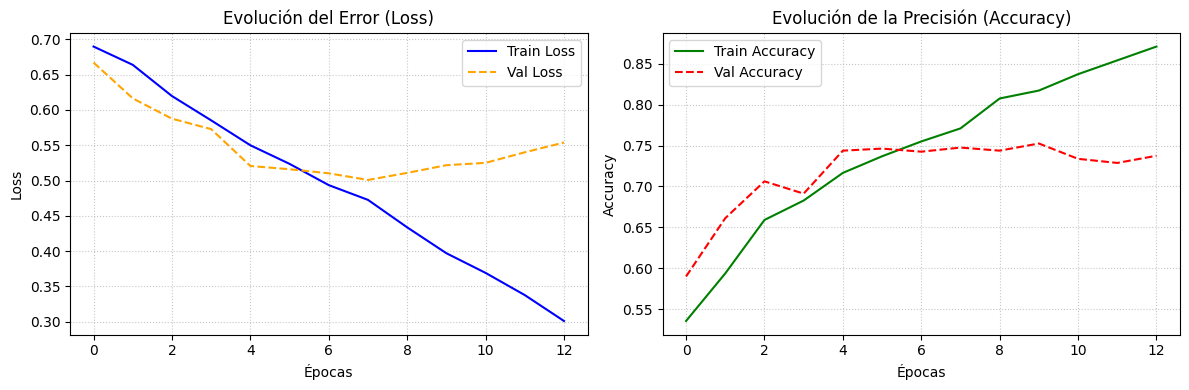

In [9]:
# 3. Mostramos el historial de entrenamiento
# Vamos a sacar la telemetría: una gráfica para el error (loss) y otra para el acierto (accuracy)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Gráfica de Loss (Error: cuanto más bajo, mejor)
ax1.plot(historial.history['loss'], label='Train Loss', color='blue')
ax1.plot(historial.history['val_loss'], label='Val Loss', color='orange', linestyle='--')
ax1.set_title('Evolución del Error (Loss)')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, linestyle=':', alpha=0.7)

# Gráfica de Accuracy (Precisión: cuanto más alta, mejor)
ax2.plot(historial.history['accuracy'], label='Train Accuracy', color='green')
ax2.plot(historial.history['val_accuracy'], label='Val Accuracy', color='red', linestyle='--')
ax2.set_title('Evolución de la Precisión (Accuracy)')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Accuracy')
ax2.legend()
ax2.grid(True, linestyle=':', alpha=0.7)

plt.tight_layout()
plt.show()

En la gráfica de la izquierda (Evolución del Error), a partir de la época 8 la línea azul (Train Loss) sigue bajando, pero la línea naranja de validación (Val Loss) empieza a subir. Esto indica que el modelo empezaba a memorizar los datos de entrenamiento (overfitting) en lugar de aprender a generalizar. El sistema cortó a tiempo en la época 13 y recuperó la configuración óptima de la época 8.

---

# Reporte de clasificación y matriz de confusión

Evaluando el modelo en el conjunto de Test...
Pérdida (Loss) en Test: 0.5226
Precisión (Accuracy) en Test: 0.7380

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
--- Reporte de Clasificación ---
              precision    recall  f1-score   support

        gato       0.74      0.73      0.73       500
       perro       0.73      0.75      0.74       500

    accuracy                           0.74      1000
   macro avg       0.74      0.74      0.74      1000
weighted avg       0.74      0.74      0.74      1000

--- Matriz de Confusión ---


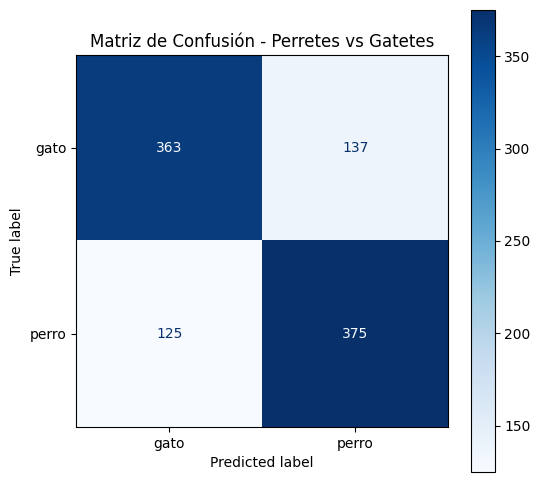

In [10]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# 1. Evaluación general del modelo con los datos de prueba (test)
print("Evaluando el modelo en el conjunto de Test...")
test_loss, test_accuracy = modelo.evaluate(X_test_norm, y_test_enc, verbose=0)
print(f"Pérdida (Loss) en Test: {test_loss:.4f}")
print(f"Precisión (Accuracy) en Test: {test_accuracy:.4f}\n")

# 2. Generar las predicciones
# La capa final usa activación 'sigmoid', por lo que devuelve probabilidades de 0 a 1.
# Por convención, >= 0.5 se asigna a la clase 1 y < 0.5 a la clase 0.
y_pred_prob = modelo.predict(X_test_norm)
y_pred = (y_pred_prob >= 0.5).astype(int)

# 3. Reporte de clasificación
print("--- Reporte de Clasificación ---")
# Recuperamos los nombres reales de las clases que asignó el LabelEncoder ('gato', 'perro')
etiquetas = le.classes_ 
print(classification_report(y_test_enc, y_pred, target_names=etiquetas))

# 4. Matriz de Confusión
print("--- Matriz de Confusión ---")
cm = confusion_matrix(y_test_enc, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=etiquetas)

# Dibujamos la matriz con un mapa de color azul
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(cmap='Blues', ax=ax, values_format='d')
plt.title('Matriz de Confusión - Perretes vs Gatetes')
plt.show()

el modelo se ha equivocado de la siguiente manera:

- 137 gatos fueron clasificados incorrectamente como perros.

- 125 perros fueron clasificados incorrectamente como gatos.

---

# Selección de imágenes

Total Gatos clasificados como Perros: 137 -> Seleccionamos el 10%: 13 imágenes.
Total Perros clasificados como Gatos: 125 -> Seleccionamos el 10%: 12 imágenes.


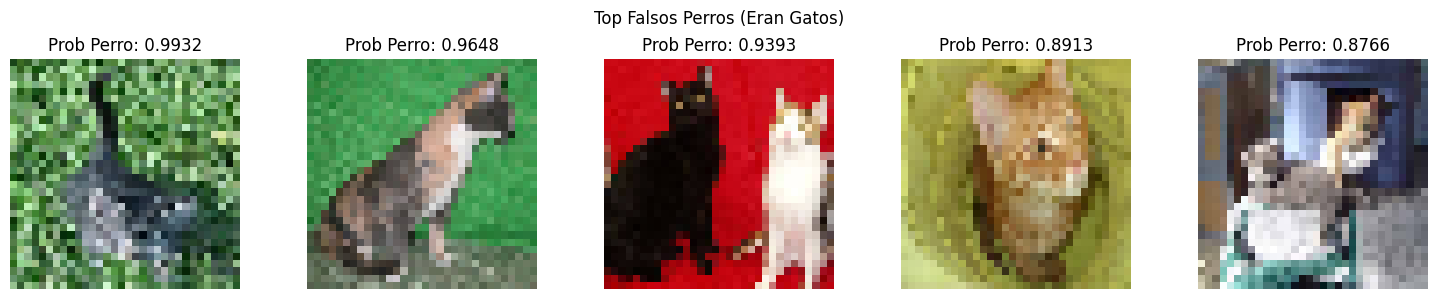

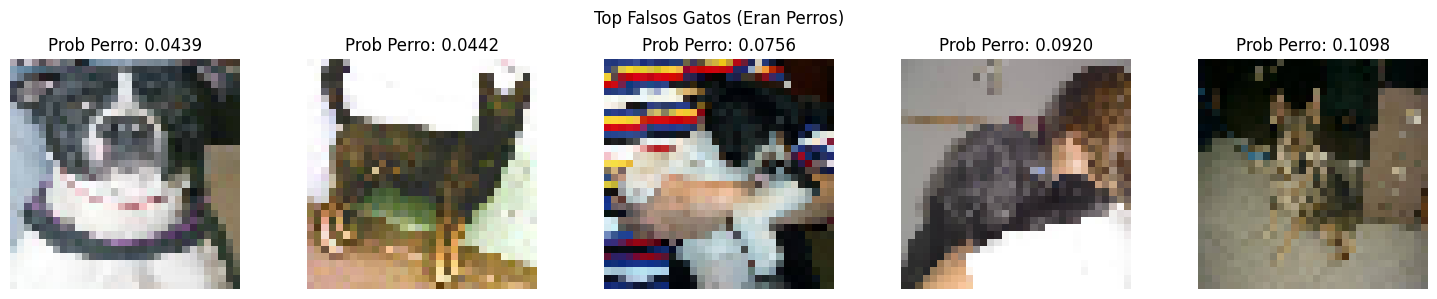

In [11]:
# Asegurarnos de que los arrays sean unidimensionales para poder filtrarlos bien
probabilidades = y_pred_prob.flatten()
y_true = y_test_enc.flatten()
y_pred_clases = y_pred.flatten()

# 1. Identificar todos los índices donde el modelo falló
errores_idx = np.where(y_true != y_pred_clases)[0]

# 2. Separar los errores y ordenarlos por el nivel de confianza (probabilidad)
# CASO A: Era GATO (0) pero dijo PERRO (1). Mayor confianza = probabilidad más cercana a 1.0
idx_falsos_perros = [i for i in errores_idx if y_true[i] == 0]
idx_falsos_perros.sort(key=lambda i: probabilidades[i], reverse=True)

# CASO B: Era PERRO (1) pero dijo GATO (0). Mayor confianza = probabilidad más cercana a 0.0
idx_falsos_gatos = [i for i in errores_idx if y_true[i] == 1]
idx_falsos_gatos.sort(key=lambda i: probabilidades[i], reverse=False)

# 3. Calcular el 10% de cada grupo (asegurando coger al menos 1 imagen)
n_top_falsos_perros = max(1, int(len(idx_falsos_perros) * 0.10))
n_top_falsos_gatos = max(1, int(len(idx_falsos_gatos) * 0.10))

top_falsos_perros = idx_falsos_perros[:n_top_falsos_perros]
top_falsos_gatos = idx_falsos_gatos[:n_top_falsos_gatos]

print(f"Total Gatos clasificados como Perros: {len(idx_falsos_perros)} -> Seleccionamos el 10%: {n_top_falsos_perros} imágenes.")
print(f"Total Perros clasificados como Gatos: {len(idx_falsos_gatos)} -> Seleccionamos el 10%: {n_top_falsos_gatos} imágenes.")

# 4. Visualizar algunas de estas imágenes "difíciles" (opcional pero recomendado)
def mostrar_imagenes_dificiles(indices, titulo, max_mostrar=5):
    cantidad = min(len(indices), max_mostrar)
    fig, axes = plt.subplots(1, cantidad, figsize=(15, 3))
    if cantidad == 1:
        axes = [axes]
        
    for ax, idx in zip(axes, indices[:cantidad]):
        img_rgb = cv2.cvtColor(X_test[idx], cv2.COLOR_BGR2RGB)
        ax.imshow(img_rgb)
        prob = probabilidades[idx]
        ax.set_title(f"Prob Perro: {prob:.4f}")
        ax.axis('off')
        
    plt.suptitle(titulo)
    plt.tight_layout()
    plt.show()

mostrar_imagenes_dificiles(top_falsos_perros, "Top Falsos Perros (Eran Gatos)")
mostrar_imagenes_dificiles(top_falsos_gatos, "Top Falsos Gatos (Eran Perros)")

### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 